# Heart Disease Presence Prediction — Model Training Run

> **For research and educational purposes only.** The model below is trained on a
> historical public dataset. Its output is not a medical diagnosis and not medical
> advice. See the model card for what this model must **not** be used for.

This notebook **does not train anything** — it reads the artifacts produced by

```
python -m scripts.train_heart
```

so every number shown here is the same number in `reports/heart/` and
`models/heart/metadata.json`. Re-run that script to refresh them.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import json
from pathlib import Path

import joblib
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 60)

DISEASE = "heart"
reports = Path("reports") / DISEASE
models = Path("models") / DISEASE

metrics = json.loads((reports / "metrics.json").read_text(encoding="utf-8"))
card = json.loads((models / "metadata.json").read_text(encoding="utf-8"))
shap_global = json.loads((reports / "shap_global.json").read_text(encoding="utf-8"))

print(card["module"])
print("algorithm :", card["model"]["algorithm"])
print("calibration:", card["model"]["calibration"])


Heart Disease Presence Prediction
algorithm : xgboost
calibration: sigmoid


## 1. How the data was split

Preprocessing (imputation, scaling, one-hot) happens **inside** the model pipeline, so
it is fitted on training folds only and never sees the held-out rows.


In [2]:
pd.Series(metrics["split"]).to_frame("value")

,value
n_total,303.0000
n_train,242.0000
n_test,61.0000
n_duplicate_rows,0.0000
overall_positive_rate,0.4587
train_positive_rate,0.4587
test_positive_rate,0.4590


## 2. Model comparison

Five candidate pipelines, 5-fold cross-validated on the training set.

In [3]:
pd.read_csv(reports / "model_comparison.csv")

,model,smote,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,rank_score
0,logreg,False,0.9067,0.0357,0.8934,0.0660,0.7945,0.0993,0.8584,0.0858,0.8181,0.0622,0.8789
1,random_forest,False,0.9015,0.0350,0.9018,0.0409,0.7498,0.1352,0.8109,0.0595,0.7711,0.0827,0.8713
2,xgboost,False,0.8801,0.0316,0.8847,0.0335,0.7854,0.0946,0.8024,0.0719,0.7862,0.0413,0.8630
3,svc,False,0.8770,0.0349,0.8755,0.0493,0.7589,0.1286,0.8106,0.0610,0.7735,0.0659,0.8528
4,lightgbm,False,0.8583,0.0275,0.8535,0.0326,0.7490,0.0924,0.7891,0.0751,0.7602,0.0306,0.8345


### Was the winner meaningfully better?

`selection_margin` compares the tuned top-2 against the fold-to-fold standard deviation.
When the gap is smaller than that noise, the leaderboard is **not** a quality ranking.


In [4]:
pd.Series(metrics["selection_margin"]).to_frame("value")

,value
selected,xgboost
selected_tuned_roc_auc,0.907901
runner_up,logreg
runner_up_tuned_roc_auc,0.907405
gap,0.000495
cv_roc_auc_std,0.031617
decisive,False
reasons_to_doubt,[the gap (0.0005) is smaller than the selected...
gap_within_cv_noise,True


In [5]:
display(Markdown((reports / "SELECTION.md").read_text(encoding="utf-8")))

# Model selection — heart

Selection criteria (in order): ROC-AUC and PR-AUC (discrimination), then recall/sensitivity for the positive class, then calibration. **Not** accuracy.

## Cross-validated comparison (training set, 5-fold stratified CV)

| model | smote | roc_auc_mean | roc_auc_std | pr_auc_mean | pr_auc_std | recall_mean | recall_std | precision_mean | precision_std | f1_mean | f1_std | rank_score |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| logreg | False | 0.9067 | 0.0357 | 0.8934 | 0.0660 | 0.7945 | 0.0993 | 0.8584 | 0.0858 | 0.8181 | 0.0622 | 0.8789 |
| random_forest | False | 0.9015 | 0.0350 | 0.9018 | 0.0409 | 0.7498 | 0.1352 | 0.8109 | 0.0595 | 0.7711 | 0.0827 | 0.8713 |
| xgboost | False | 0.8801 | 0.0316 | 0.8847 | 0.0335 | 0.7854 | 0.0946 | 0.8024 | 0.0719 | 0.7862 | 0.0413 | 0.8630 |
| svc | False | 0.8770 | 0.0349 | 0.8755 | 0.0493 | 0.7589 | 0.1286 | 0.8106 | 0.0610 | 0.7735 | 0.0659 | 0.8528 |
| lightgbm | False | 0.8583 | 0.0275 | 0.8535 | 0.0326 | 0.7490 | 0.0924 | 0.7891 | 0.0751 | 0.7602 | 0.0306 | 0.8345 |

## Tuning (RandomizedSearchCV, scoring = ROC-AUC)

- **xgboost**: CV ROC-AUC 0.9079
  - params: `{'clf__colsample_bytree': 0.6431565707973218, 'clf__learning_rate': 0.011128194768838964, 'clf__max_depth': 2, 'clf__min_child_weight': 4, 'clf__n_estimators': 295, 'clf__reg_lambda': 1.2205294397769415, 'clf__subsample': 0.6557325817623503}`
- **logreg**: CV ROC-AUC 0.9074
  - params: `{'clf__C': 1.0129197956845732, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}`
- **random_forest**: CV ROC-AUC 0.9061
  - params: `{'clf__max_depth': 8, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 6, 'clf__min_samples_split': 11, 'clf__n_estimators': 676}`

## Selected: `xgboost`

`xgboost` was chosen from 5 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `logreg` first before tuning, with `xgboost` at rank 3. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: xgboost 0.9079, logreg 0.9074, random_forest 0.9061; `xgboost` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion.

### How decisive was this?

**Not decisive.** `xgboost` beat `logreg` by 0.0005 cross-validated ROC-AUC, but:

- the gap (0.0005) is smaller than the selected model's fold-to-fold standard deviation (0.0316).
- the gap (0.0005) is below 0.005, the practical resolution of ROC-AUC at this sample size.

Read the leaderboard as *these models perform comparably*, not as a quality ranking. A different random seed could reorder them. The choice of algorithm here should not be presented as a finding.

---
*Generated by `ml.training.experiment.run_experiment`. Every number above comes from that run.*


## 3. Calibration

The wrapper is chosen on **out-of-fold training** scores. The test-set table below is
reported for transparency only — choosing on it would make the test metrics optimistic.


In [6]:
print("selection (training out-of-fold):")
display(pd.DataFrame(metrics["calibration_selection_train_cv"]).set_index("method"))
print("\nreported only (test set) — NOT used to choose:")
display(pd.DataFrame(metrics["calibration_test_comparison"]).set_index("method"))
print("\nchosen:", card["model"]["calibration"])
print(card["model"]["calibration_rationale"])


selection (training out-of-fold):


,brier,roc_auc
method,,
raw,0.129782,0.896637
sigmoid,0.128458,0.894024
isotonic,0.130883,0.880682



reported only (test set) — NOT used to choose:


,brier,roc_auc
method,,
raw,0.100300,0.950216
sigmoid,0.089331,0.953463
isotonic,0.080823,0.954004



chosen: sigmoid
Selected 'sigmoid' by out-of-fold Brier score on the training set: 0.1285 vs raw 0.1298; cross-validated ROC-AUC 0.8940 vs raw 0.8966 (tolerance 0.01). The test set played no part in this choice.


## 4. Held-out test performance

In [7]:
rows = {
    "threshold 0.5": metrics["test_set_threshold_0.5"],
    "sensitivity-oriented": {k: v for k, v in metrics["test_set_alternative_threshold"].items()
                             if k != "threshold_rule"},
}
display(pd.DataFrame(rows).loc[
    ["n", "threshold", "roc_auc", "pr_auc", "recall_sensitivity", "specificity",
     "precision", "f1", "accuracy", "brier", "cm_tn", "cm_fp", "cm_fn", "cm_tp"]
])
print(metrics["test_set_alternative_threshold"]["threshold_rule"])


,threshold 0.5,sensitivity-oriented
n,61.000000,61.000000
threshold,0.500000,0.643585
roc_auc,0.953463,0.953463
pr_auc,0.949561,0.949561
recall_sensitivity,0.892857,0.821429
specificity,0.878788,0.939394
precision,0.862069,0.920000
f1,0.877193,0.867925
accuracy,0.885246,0.885246
brier,0.089331,0.089331


Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it.


### Which threshold should you read?

0.5 is a convention, not a decision rule. On a low-prevalence problem a well-calibrated
model should rarely output a probability above 0.5 — most people really do have a
below-even chance — so thresholding there gives high specificity and low recall. That
looks like a broken model and is not one.


In [8]:
note = metrics.get("diagnostics", {}).get("operating_point_note")
display(Markdown(f"> {note}" if note else "_No operating-point note recorded._"))


> Positive-class prevalence is 0.4590. At threshold 0.5 the model recovers 0.8929 of positives at 0.8788 specificity; at the sensitivity-oriented threshold 0.6436 it recovers 0.8214 at 0.9394 specificity. The two operating points are close, so 0.5 is a reasonable default here.

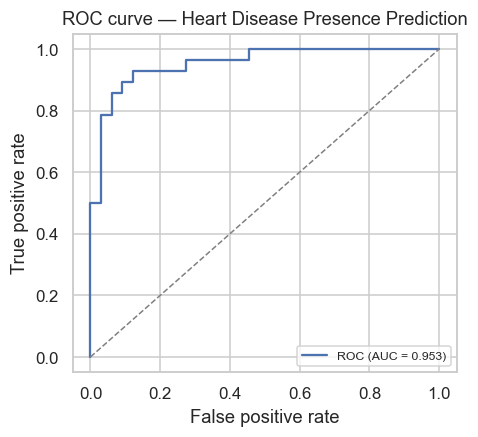

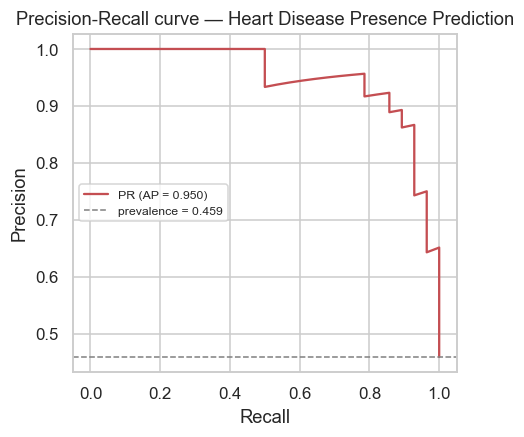

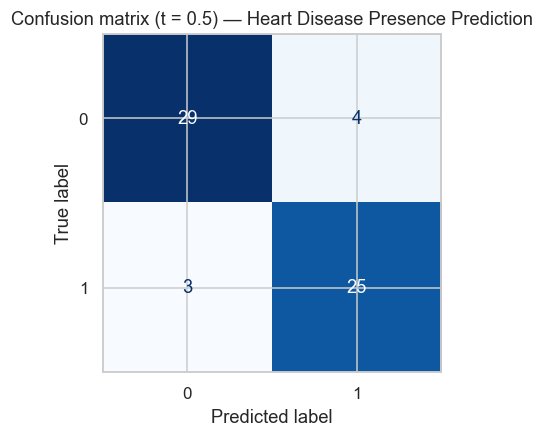

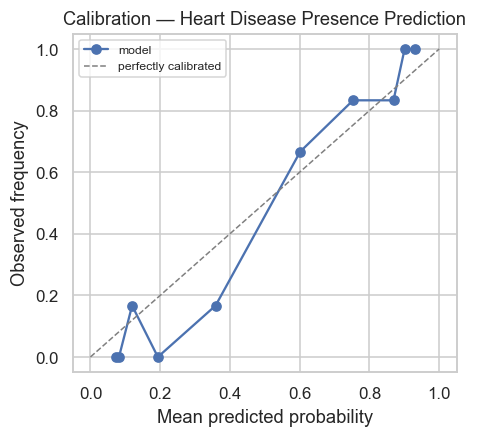

In [9]:
for name in ["roc_curve", "pr_curve", "confusion_matrix", "calibration_curve"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### Threshold sweep

How precision, recall and specificity trade off across the decision threshold.

In [10]:
pd.read_csv(reports / "threshold_sweep.csv")

,threshold,precision,recall_sensitivity,specificity,f1,accuracy
0,0.05,0.4590,1.0000,0.0000,0.6292,0.4590
1,0.10,0.5957,1.0000,0.4242,0.7467,0.6885
2,0.15,0.6512,1.0000,0.5455,0.7887,0.7541
3,0.20,0.7105,0.9643,0.6667,0.8182,0.8033
4,0.25,0.7500,0.9643,0.7273,0.8438,0.8361
5,0.30,0.7647,0.9286,0.7576,0.8387,0.8361
6,0.35,0.8125,0.9286,0.8182,0.8667,0.8689
7,0.40,0.8125,0.9286,0.8182,0.8667,0.8689
8,0.45,0.8387,0.9286,0.8485,0.8814,0.8852
9,0.50,0.8621,0.8929,0.8788,0.8772,0.8852


## 4b. What actually drives this score?

A high ROC-AUC is not by itself evidence that the model learned clinical structure — it
can also come from how the data was collected. The probe below discards **every measured
value** and trains only on *which values are missing*. If that alone reproduces most of
the headline score, the model is largely reading which tests a clinician chose to order.

That is not train/test leakage — the split stays clean — but it is a ceiling on how far
the result transfers to a setting where these tests are ordered routinely.


In [11]:
diag = metrics.get("diagnostics", {})
print(diag.get("attribution_note", "(no diagnostics recorded)"))
print()

probe = diag.get("missingness_only_probe")
if probe:
    print("missingness-indicators-only model:")
    for k in ("n_indicator_features", "cv_roc_auc_mean", "cv_roc_auc_std",
              "test_roc_auc", "test_pr_auc", "test_accuracy"):
        if k in probe:
            print(f"  {k:<22} {probe[k]}")
    print(f"\n  full model test ROC-AUC {metrics['test_set_threshold_0.5']['roc_auc']:.4f}")
else:
    print("No missing values in this dataset — measurement pattern cannot carry signal.")

print("\ncomplete-case analysis (why it was not used instead):")
print(" ", diag.get("complete_case"))


Missingness indicators alone reach only test ROC-AUC 0.4394 against the full model's 0.9535 (gap +0.5141), so the measurement pattern does not explain most of the performance.

missingness-indicators-only model:
  n_indicator_features   2
  cv_roc_auc_mean        0.5
  cv_roc_auc_std         0.0
  test_roc_auc           0.4393939393939394
  test_pr_auc            0.45901639344262296
  test_accuracy          0.47540983606557374

  full model test ROC-AUC 0.9535

complete-case analysis (why it was not used instead):
  {'n_total': 303, 'n_complete_cases': 297, 'pct_retained': 98.02, 'positive_rate_all': 0.4587, 'positive_rate_complete_cases': 0.4613}


In [12]:
miss_csv = reports / "missingness_vs_target.csv"
if miss_csv.exists():
    display(Markdown("**Is a column's missingness itself predictive of the target?**"))
    display(pd.read_csv(miss_csv))
else:
    print("No missing values to analyse.")


**Is a column's missingness itself predictive of the target?**

,column,n_missing,pct_missing,positive_rate_when_missing,positive_rate_when_present,difference,overall_positive_rate
0,ca,4,1.32,0.25,0.4615,-0.2115,0.4587
1,thal,2,0.66,0.50,0.4585,0.0415,0.4587


### 4c. What could any model achieve on these features?

When two rows carry an identical feature vector but different outcomes, no model that sees
only these features can get both right. That is irreducible error, and it caps accuracy
regardless of the algorithm. Reported so the gap to 1.0 is attributed honestly — and so
that it is *not* used to excuse a model sitting far below the bound.


In [13]:
dup = diag.get("duplicate_feature_vectors")
display(Markdown(f"> {diag.get('duplicate_conflict_note', '(not recorded)')}"))
if dup:
    display(pd.Series(dup).to_frame("value"))


> No two rows share an identical feature vector with conflicting labels, so the features impose no measurable ceiling of this kind.

,value
n_rows,303.0
n_unique_feature_vectors,303.0
n_rows_sharing_a_feature_vector,0.0
pct_rows_sharing_a_feature_vector,0.0
n_duplicate_groups,0.0
n_conflicted_groups,0.0
n_rows_in_conflicted_groups,0.0
n_unwinnable_rows,0.0
max_achievable_accuracy,1.0


### 4d. Did SMOTE actually help?

"Use SMOTE for imbalanced data" is repeated far more often than it is checked. Where this
comparison was run, the selected model was cross-validated on identical folds under SMOTE
and under class weighting. SMOTE resamples **inside** each fold's training portion only.

Watch PR-AUC rather than recall: both strategies move the operating point, so recall at a
fixed 0.5 threshold swings hard while the threshold-free ranking barely changes.


In [14]:
imb_csv = reports / "imbalance_comparison.csv"
if imb_csv.exists():
    display(Markdown(f"> {diag.get('imbalance_note', '')}"))
    display(pd.read_csv(imb_csv))
else:
    print("Imbalance strategies were not compared for this disease.")


Imbalance strategies were not compared for this disease.


## 5. Explainability (SHAP)

SHAP values are computed on the transformed matrix and summed back onto the **original**
feature names. `additivity_max_error` is the largest gap between `base value + sum(SHAP)`
and the model's actual output — near zero means the explanation really does reconstruct
this model rather than being a plausible-looking set of numbers.


In [15]:
print("explainer:", shap_global["explainer"])
print("additivity max error:", shap_global["additivity_max_error"])
display(pd.DataFrame(shap_global["global_importance"]))


explainer: tree
additivity max error: 1.430511474609375e-06


,rank,feature,mean_abs_shap,mean_shap,description
0,1,thal,0.569342,-0.015819,"Thalassemia (3 normal, 6 fixed defect, 7 rever..."
1,2,ca,0.552276,0.072019,Number of major vessels (0-3) coloured by fluo...
2,3,cp,0.508816,-0.051703,"Chest pain type (1 typical angina, 2 atypical ..."
3,4,sex,0.193749,-0.007381,"Sex (1 = male, 0 = female)"
4,5,slope,0.193205,0.013609,Slope of the peak exercise ST segment (1 upslo...
5,6,oldpeak,0.189320,-0.007609,ST depression induced by exercise relative to ...
6,7,thalach,0.170303,0.010983,Maximum heart rate achieved
7,8,exang,0.111690,-0.001134,"Exercise-induced angina (1 = yes, 0 = no)"
8,9,chol,0.093519,-0.027107,Serum cholesterol (mg/dl)
9,10,age,0.090698,0.006004,Age in years


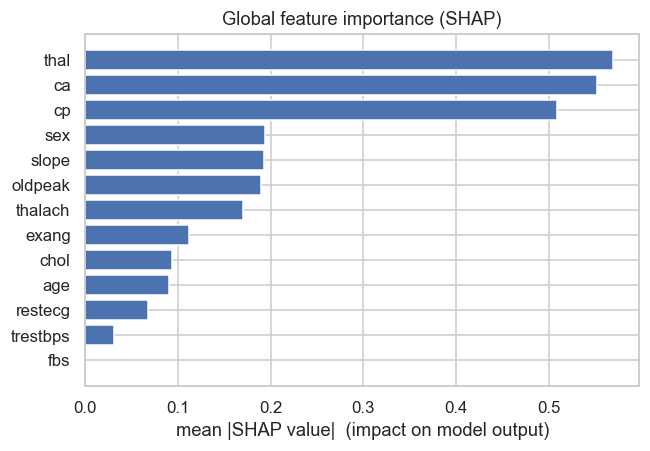

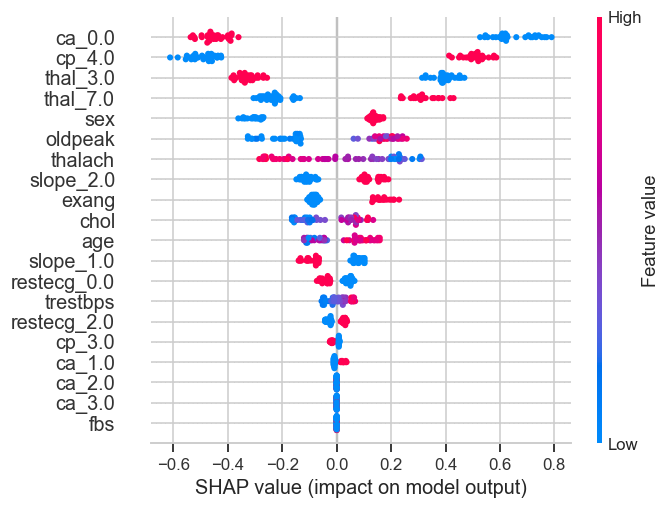

In [16]:
for name in ["shap_global_importance", "shap_beeswarm"]:
    png = reports / "figures" / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))


### A single explained case

Signed contributions for one held-out patient. Positive pushes the model toward the
positive class, negative away from it. This is an explanation of **the model's output**,
not a clinical account of why this person is or is not ill.


In [17]:
local = shap_global["example_local_explanation"]
print("base value           :", round(local["base_value"], 4))
print("predicted probability:", round(local["predicted_probability"], 4))
display(pd.DataFrame(local["contributions"]))


base value           : 0.0089
predicted probability: 0.1347


,feature,value,contribution,description
0,thal,3.0,-0.651462,"Thalassemia (3 normal, 6 fixed defect, 7 rever..."
1,cp,3.0,-0.512826,"Chest pain type (1 typical angina, 2 atypical ..."
2,ca,0.0,-0.475833,Number of major vessels (0-3) coloured by fluo...
3,thalach,187.0,-0.267940,Maximum heart rate achieved
4,oldpeak,3.5,0.157004,ST depression induced by exercise relative to ...
5,sex,1.0,0.148676,"Sex (1 = male, 0 = female)"
6,age,37.0,-0.103127,Age in years
7,exang,0.0,-0.096623,"Exercise-induced angina (1 = yes, 0 = no)"
8,slope,3.0,-0.065534,Slope of the peak exercise ST segment (1 upslo...
9,chol,250.0,0.053688,Serum cholesterol (mg/dl)


## 6. Model card

Intended use, out-of-scope use, and the limitations of this model.


In [18]:
display(Markdown((models / "MODEL_CARD.md").read_text(encoding="utf-8")))

# Model card — Heart Disease Presence Prediction

> **For research and educational purposes only. Predictions generated by this system are based on machine-learning models trained on historical public datasets and must not be interpreted as medical diagnosis or professional medical advice.**

_Created 2026-09-02._

## Intended use

Research and education: exploring how machine-learning models relate routinely collected clinical or survey variables to a recorded disease label, and how those relationships can be explained (SHAP). Suitable for teaching, methodology demonstrations and portfolio work.

### Out of scope

- Any clinical decision, diagnosis, triage, screening or treatment planning.
- Use on an individual patient to determine whether they have, or will develop, a disease.
- Deployment in a healthcare setting, or as a substitute for a qualified clinician.
- Populations, care settings or measurement protocols unlike the training cohort.

## Dataset

| field | value |
|---|---|
| `source` | UCI Machine Learning Repository |
| `uci_id` | 45 |
| `positive_class_meaning` | angiographic heart disease present (>50% diameter narrowing) |
| `n_rows` | 303 |
| `n_features` | 13 |
| `n_numeric` | 5 |
| `n_categorical` | 5 |
| `n_binary` | 3 |
| `target` | heart_disease_present |
| `class_0` | 164 |
| `class_1` | 139 |
| `positive_rate` | 0.4587 |
| `total_missing_cells` | 6 |

## Model

| field | value |
|---|---|
| `algorithm` | xgboost |
| `calibration` | sigmoid |
| `calibration_rationale` | Selected 'sigmoid' by out-of-fold Brier score on the training set: 0.1285 vs raw 0.1298; cross-validated ROC-AUC 0.8940 vs raw 0.8966 (tolerance 0.01). The test set played no part in this choice. |
| `selection_rationale` | `xgboost` was chosen from 5 candidate pipelines. The cross-validated ranking (0.4·ROC-AUC + 0.4·PR-AUC + 0.2·recall) put `logreg` first before tuning, with `xgboost` at rank 3. After randomised hyper-parameter search the tuned cross-validated ROC-AUC scores were: xgboost 0.9079, logreg 0.9074, random_forest 0.9061; `xgboost` was highest and was refit on the full training set. Accuracy was recorded but was not used as a selection criterion. |

> **The margin of selection is not meaningful.** `xgboost` beat `logreg` by 0.0005 cross-validated ROC-AUC, but the gap (0.0005) is smaller than the selected model's fold-to-fold standard deviation (0.0316); the gap (0.0005) is below 0.005, the practical resolution of ROC-AUC at this sample size. Treat the candidate models as performing comparably; a different random seed could easily reorder them. This choice should not be read as evidence that this algorithm is better suited to the problem.

Hyperparameters:

```json
{
  "clf__colsample_bytree": 0.6431565707973218,
  "clf__learning_rate": 0.011128194768838964,
  "clf__max_depth": 2,
  "clf__min_child_weight": 4,
  "clf__n_estimators": 295,
  "clf__reg_lambda": 1.2205294397769415,
  "clf__subsample": 0.6557325817623503
}
```

## Protocol

| field | value |
|---|---|
| `random_state` | 42 |
| `test_size` | 0.2000 |
| `cv_folds` | 5 |
| `split_strategy` | stratified_holdout |
| `preprocessing` | Inside the model pipeline only: numeric = median imputation + standard scaling; categorical = most-frequent imputation + one-hot (handle_unknown='ignore'); binary = most-frequent imputation. Fitted on training folds only — never on the full dataset. |
| `selection_criteria` | Composite of cross-validated ROC-AUC (0.4), PR-AUC (0.4) and recall (0.2); accuracy is reported but not used to select. |

## Performance

_All figures below are measured on the held-out test set (or by cross-validation on the training set where stated). None are estimates._

### Cross-validation (training set)

| metric | value |
|---|---|
| `smote` | False |
| `roc_auc_mean` | 0.8801 |
| `roc_auc_std` | 0.0316 |
| `pr_auc_mean` | 0.8847 |
| `pr_auc_std` | 0.0335 |
| `recall_mean` | 0.7854 |
| `recall_std` | 0.0946 |
| `precision_mean` | 0.8024 |
| `precision_std` | 0.0719 |
| `f1_mean` | 0.7862 |
| `f1_std` | 0.0413 |
| `rank_score` | 0.8630 |

### Held-out test set (threshold 0.5)

| metric | value |
|---|---|
| `n` | 61 |
| `prevalence` | 0.4590 |
| `threshold` | 0.5000 |
| `accuracy` | 0.8852 |
| `precision` | 0.8621 |
| `recall_sensitivity` | 0.8929 |
| `specificity` | 0.8788 |
| `f1` | 0.8772 |
| `roc_auc` | 0.9535 |
| `pr_auc` | 0.9496 |
| `brier` | 0.0893 |
| `cm_tn` | 29 |
| `cm_fp` | 4 |
| `cm_fn` | 3 |
| `cm_tp` | 25 |

### Held-out test set (sensitivity-oriented threshold)

| metric | value |
|---|---|
| `n` | 61 |
| `prevalence` | 0.4590 |
| `threshold` | 0.6436 |
| `accuracy` | 0.8852 |
| `precision` | 0.9200 |
| `recall_sensitivity` | 0.8214 |
| `specificity` | 0.9394 |
| `f1` | 0.8679 |
| `roc_auc` | 0.9535 |
| `pr_auc` | 0.9496 |
| `brier` | 0.0893 |
| `cm_tn` | 31 |
| `cm_fp` | 2 |
| `cm_fn` | 5 |
| `cm_tp` | 23 |
| `threshold_rule` | Youden's J (max sensitivity + specificity - 1) maximised on out-of-fold predictions over the TRAINING set, then applied unchanged to the test set. The test set played no part in choosing it. |

### Which threshold to read

> Positive-class prevalence is 0.4590. At threshold 0.5 the model recovers 0.8929 of positives at 0.8788 specificity; at the sensitivity-oriented threshold 0.6436 it recovers 0.8214 at 0.9394 specificity. The two operating points are close, so 0.5 is a reasonable default here.

### Calibration comparison

| method | brier | roc_auc |
|---|---|---|
| raw | 0.1003 | 0.9502 |
| sigmoid | 0.0893 | 0.9535 |
| isotonic | 0.0808 | 0.9540 |

### What actually drives this score

> Missingness indicators alone reach only test ROC-AUC 0.4394 against the full model's 0.9535 (gap +0.5141), so the measurement pattern does not explain most of the performance.

Probe detail: a logistic regression trained on 2 binary *is-this-value-missing* indicators, with every measured value discarded, reaches test ROC-AUC 0.4394 (PR-AUC 0.4590, accuracy 0.4754).

Complete-case analysis was not used as an alternative: dropping every row with a missing value would retain 297/303 rows (98.02%) and shift the positive rate from 0.4587 to 0.4613.

## Explainability

Method: SHAP, aggregated from the transformed columns back to original features

| rank | feature | mean_abs_shap | mean_shap | description |
|---|---|---|---|---|
| 1 | thal | 0.5693 | -0.0158 | Thalassemia (3 normal, 6 fixed defect, 7 reversible defect) |
| 2 | ca | 0.5523 | 0.0720 | Number of major vessels (0-3) coloured by fluoroscopy |
| 3 | cp | 0.5088 | -0.0517 | Chest pain type (1 typical angina, 2 atypical angina, 3 non-anginal, 4 asymptomatic) |
| 4 | sex | 0.1937 | -0.0074 | Sex (1 = male, 0 = female) |
| 5 | slope | 0.1932 | 0.0136 | Slope of the peak exercise ST segment (1 upsloping, 2 flat, 3 downsloping) |
| 6 | oldpeak | 0.1893 | -0.0076 | ST depression induced by exercise relative to rest |
| 7 | thalach | 0.1703 | 0.0110 | Maximum heart rate achieved |
| 8 | exang | 0.1117 | -0.0011 | Exercise-induced angina (1 = yes, 0 = no) |
| 9 | chol | 0.0935 | -0.0271 | Serum cholesterol (mg/dl) |
| 10 | age | 0.0907 | 0.0060 | Age in years |

## Limitations

- Very small sample: 303 patients from a single site (Cleveland Clinic), collected in the late 1980s. Confidence intervals on every metric are wide and the test set is ~61 patients.
- Case mix is referral-based (patients already sent for angiography), so the positive rate (~46%) is far higher than in a general population. Predicted probabilities reflect that cohort, not the public.
- 'ca' (4 missing) and 'thal' (2 missing) are imputed inside the pipeline; both are strong predictors.
- 'chol' contains 0 values that are almost certainly 'not measured' sentinels rather than true zeros; they are left as-is and not treated as missing.
- Features such as 'thal', 'ca' and 'oldpeak' come from tests (fluoroscopy, exercise ECG) that are themselves ordered because disease is already suspected — the model is not a general-population screen.
- Encodings for 'cp', 'slope' and 'thal' follow the Cleveland processed release; other heart datasets code these differently.

## Risk bands

_Illustrative presentation buckets for a model-estimated probability. Not clinical decision thresholds; they carry no medical meaning._

| label | min | max |
|---|---|---|
| low | 0.00 | 0.33 |
| moderate | 0.33 | 0.66 |
| high | 0.66 | 1.01 |

---
*Generated by `ml.model_card.write_model_card`.*
